<a href="https://colab.research.google.com/github/Quantum00000/Deep_Learning_with_Pytorch/blob/main/DeepLearning_Computer_vision_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
import torchvision
from torchvision import datasets

In [3]:
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None,
    download=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


In [4]:
test_data =datasets.FashionMNIST(
    root="data",
    train=False,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None,
    download=True
)

In [5]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [6]:
image, label=train_data[0]

In [7]:
class_name=train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [9]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

# **Visualization**

In [10]:
import matplotlib.pyplot as plt

In [11]:
#image.shape
#image ,label =train_data[9]
#print(image.shape)
#plt.title(class_name[label])
#plt.imshow(image.squeeze(),cmap="gray")
#plt.show()


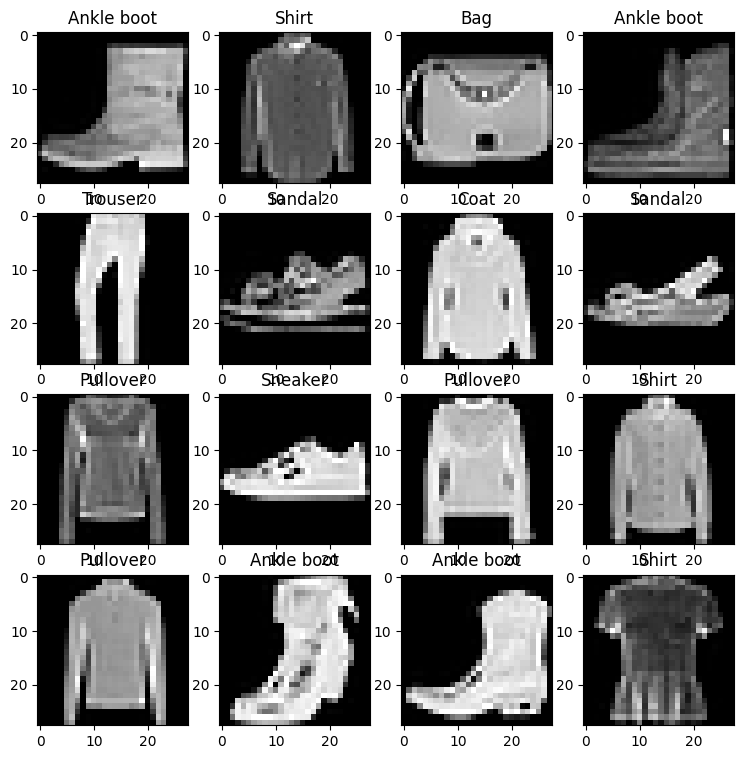

In [12]:
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label =train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(class_name[label])

DATA LOADER

In [13]:
from torch.utils.data import DataLoader

In [14]:
train_dataloader=DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

test_dataloader=DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

In [15]:
train_features_batch,train_label_batch=next(iter(train_dataloader))

Text(0.5, 1.0, 'Shirt')

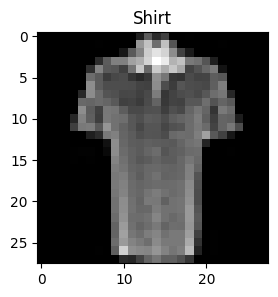

In [16]:
torch.manual_seed(42)
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,label=train_features_batch[random_idx],train_label_batch[random_idx]
plt.figure(figsize=(3,3))
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_name[label])

we have now converted batch data(from dataloader) back into required data

# **Let Build the Model**

In [17]:
from torch import nn

In [18]:
flatten_model=nn.Flatten()

x=train_features_batch[0]
output=flatten_model(x)

The nn.Flatten() layer took our shape from [color_channels, height, width] to [color_channels, height*width]

Creating Baseline Model

In [19]:
class FashionMNISTModelv0(nn.Module):
  def __init__(self,input_shape:int, hidden_unit:int,output_shape):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_unit),
        nn.Linear(in_features=hidden_unit,out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)

In [20]:
torch.manual_seed(42)
model01=FashionMNISTModelv0(
    input_shape=784,
    hidden_unit=20 #Number of neuron per hidden layer
    ,
    output_shape=len(class_name)
)

In [21]:
model01.to("cpu")

FashionMNISTModelv0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=20, bias=True)
    (2): Linear(in_features=20, out_features=10, bias=True)
  )
)

Loss Function,optimizer,evaluation matrix

In [22]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model01.parameters(),lr=0.01)

In [23]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc


In [24]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [25]:
from tqdm.auto import tqdm

torch.manual_seed(42)

epochs=3

for epoch in (range(epochs)):
  train_loss=0
  model01.to(device)
  for batch, (X,y) in enumerate(train_dataloader):
    X,y=X.to(device),y.to(device)
    y_pred=model01(X)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch%400==0:
      print(f"Looked at:{batch*len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss/=len(train_dataloader)
  test_loss,test_acc=0,0
  model01.eval()
  with torch.inference_mode():
    for X,y in test_dataloader:
      X,y=X.to(device),y.to(device)
      test_pred=model01(X)
      test_loss+=loss_fn(test_pred,y)
      test_acc+=accuracy_fn(y,test_pred.argmax(dim=1))
    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)
  print(f"test loss:{test_loss:.5f} | test accuracy:{test_acc:.2f}%\n")



Looked at:0/60000 samples
Looked at:12800/60000 samples
Looked at:25600/60000 samples
Looked at:38400/60000 samples
Looked at:51200/60000 samples
test loss:0.62607 | test accuracy:78.62%

Looked at:0/60000 samples
Looked at:12800/60000 samples
Looked at:25600/60000 samples
Looked at:38400/60000 samples
Looked at:51200/60000 samples
test loss:0.53744 | test accuracy:81.35%

Looked at:0/60000 samples
Looked at:12800/60000 samples
Looked at:25600/60000 samples
Looked at:38400/60000 samples
Looked at:51200/60000 samples
test loss:0.50705 | test accuracy:82.21%



## **Model Evaluation**

In [26]:
torch.manual_seed(42)
def model_eval(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    accuracy_fn
):
  eval_loss,eval_acc= 0,0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for X,y in data_loader:
      X,y=X.to(device),y.to(device)

      eval_pred=model(X)

      eval_loss+=loss_fn(eval_pred,y)
      eval_acc+=accuracy_fn(y,eval_pred.argmax(dim=1))

    eval_loss/=len(data_loader)
    eval_acc/=len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": eval_loss.item(),
            "model_acc": eval_acc}

In [27]:
model01_result=model_eval(model01,test_dataloader,loss_fn,accuracy_fn)

# **Non_linear**

In [28]:
class FashionMNISTmodel02(nn.Module):
  def __init__(self,input_shape:int,hidden_unit:int,output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit,out_features=output_shape),
        nn.ReLU()
    )
  def forward(self,x=torch.Tensor):
    return self.layer_stack(x)

In [29]:
torch.manual_seed(42)
model02=FashionMNISTmodel02(
    input_shape=784,
    hidden_unit=10,
    output_shape=10
)
next(model02.parameters()).device

device(type='cpu')

In [30]:
loss_fn=nn.CrossEntropyLoss()
optimizer01=torch.optim.SGD(params=model02.parameters(),lr=0.1)

In [31]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss,train_acc=0,0
  model.to(device)
  for batch, (X,y) in enumerate(data_loader):
    #X=image, y=label
    X,y=X.to(device),y.to(device)
    y_pred=model(X)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    train_acc+=accuracy_fn(y,y_pred.argmax(dim=1))#Logit --> pred label
    optimizer.zero_grad()#makes the gradient value zero at each iteration
    loss.backward()
    optimizer.step()
  #Calculating train loss and accuracy per epoch
  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f"train loss:{train_loss:.5f} | train accuracy:{train_acc:.2f}%")


def test_step(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    device:torch.device=device):
  test_loss,test_acc=0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y=X.to(device),y.to(device)
      test_pred=model(X)
      loss=loss_fn(test_pred,y)
      test_loss+=loss
      test_acc+=accuracy_fn(y,test_pred.argmax(dim=1))

    test_loss/=len(data_loader)
    test_acc/=len(data_loader)
    print(f"test loss:{test_loss:.5f} | test accuracy:{test_acc:.2f}%\n")




In [32]:
torch.manual_seed(42)

epochs=3

for epoch in tqdm(range(epochs)):
  print(f"epoch---{epoch}\n")

  train_step(model=model02,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer01,
             accuracy_fn=accuracy_fn,
             device=device
             )

  test_step(model=model02,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            device=device
            )

  0%|          | 0/3 [00:00<?, ?it/s]

epoch---0

train loss:1.09199 | train accuracy:61.34%
test loss:0.95636 | test accuracy:65.00%

epoch---1

train loss:0.78101 | train accuracy:71.93%
test loss:0.72227 | test accuracy:73.91%

epoch---2

train loss:0.67027 | train accuracy:75.94%
test loss:0.68500 | test accuracy:75.02%



Now lets use the model_eval function

In [33]:
model02_result=model_eval(
    model=model02,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

# Building CNN model

In [34]:
class CNNmodel01(nn.Module):
  def __init__(self,input_shape:int,hidden_unit:int,output_shape:int):
    super().__init__()
    self.block1=nn.Sequential(
        nn.Conv2d(
            in_channels=input_shape,
            out_channels=hidden_unit,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1
                  ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.block2=nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_unit,
            out_channels=hidden_unit,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1
                  ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.Classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_unit*7*7,
            out_features=output_shape
        )
    )

  def forward(self,x:torch.Tensor):
      x=self.block1(x)
      x=self.block2(x)
      x=self.Classifier(x)
      return x

In [35]:
model03=CNNmodel01(
    input_shape=1,
    hidden_unit=10,
    output_shape=len(class_name)
    ).to(device)
model03


CNNmodel01(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (Classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [36]:
conv_test=nn.Conv2d(
    in_channels=1,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=0
)

In [37]:
img.shape

torch.Size([1, 28, 28])

In [38]:
conv_test(img.unsqueeze(dim=0)).shape

torch.Size([1, 10, 26, 26])

In [39]:
conv_test02=nn.Conv2d(
    in_channels=1,
    out_channels=10,
    kernel_size=(5,5),
    stride=2,
    padding=0
)

In [40]:
conv_test02(img.unsqueeze(dim=0)).shape

torch.Size([1, 10, 12, 12])

In [41]:
print(conv_test02.state_dict())

OrderedDict({'weight': tensor([[[[-0.0946,  0.0850, -0.0468,  0.1269, -0.0301],
          [-0.1590, -0.1980, -0.0075,  0.0590, -0.1179],
          [ 0.1574,  0.0949,  0.1206,  0.0921, -0.1929],
          [-0.0367,  0.1039,  0.0990, -0.1820, -0.1134],
          [ 0.1458, -0.1656,  0.1516, -0.0386,  0.0147]]],


        [[[ 0.0975,  0.0538, -0.1282,  0.0651, -0.1717],
          [-0.1009, -0.0351, -0.0400,  0.1456, -0.1092],
          [ 0.1678,  0.0932,  0.0651,  0.1424, -0.1366],
          [-0.1723,  0.0075,  0.0986,  0.1010,  0.0083],
          [ 0.1913,  0.0711,  0.0864, -0.0969,  0.0610]]],


        [[[-0.0749, -0.1616, -0.1301, -0.1207, -0.0302],
          [-0.0838,  0.1837,  0.0827, -0.1663,  0.0084],
          [ 0.1725, -0.0081,  0.0325,  0.0546, -0.0660],
          [-0.1295, -0.0750, -0.0522,  0.1574, -0.1626],
          [ 0.0269, -0.0765, -0.0213, -0.0178, -0.0776]]],


        [[[ 0.0461,  0.0473, -0.1149,  0.1229,  0.1804],
          [-0.0828,  0.0408, -0.0741,  0.1371, -0.015

In [42]:
print(conv_test02.weight.shape)
print(conv_test02.bias.shape)

torch.Size([10, 1, 5, 5])
torch.Size([10])


In [43]:
maxpoollayer=nn.MaxPool2d(kernel_size=2)

In [44]:
image_through_conv=conv_test02(img.unsqueeze(dim=0))
image_through_conv_and_maxpool=maxpoollayer(image_through_conv)
print(image_through_conv.shape)
print(image_through_conv_and_maxpool.shape)

torch.Size([1, 10, 12, 12])
torch.Size([1, 10, 6, 6])


# loss function and optimizer

In [45]:
optimizer02=torch.optim.SGD(params=model03.parameters(),lr=0.1)

In [46]:
torch.manual_seed(42)
train_step(model=model03,
           data_loader=train_dataloader,
           loss_fn=loss_fn,
           optimizer=optimizer02,
           accuracy_fn=accuracy_fn)

train loss:0.58276 | train accuracy:78.80%


In [47]:
test_step(model=model03,
           data_loader=train_dataloader,
           loss_fn=loss_fn,
           )

test loss:0.36061 | test accuracy:87.08%



In [48]:
model03_result=model_eval(model03,
           test_dataloader,loss_fn,accuracy_fn)

In [49]:
import pandas as pd

In [50]:
compare_results=pd.DataFrame([model01_result,model02_result,model03_result])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelv0,0.507052,82.208466
1,FashionMNISTmodel02,0.685001,75.019968
2,CNNmodel01,0.389790,86.122204


In [51]:
def make_prediction(model:torch.nn.Module,data:list,device:torch.device=device):
  pred_prob=[]
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample= torch.unsqueeze(sample,dim=0).to(device)
      pred_logit=model(sample)
      pred_probability=torch.softmax(pred_logit.squeeze(),dim=0)
      pred_prob.append(pred_probability.cpu())

  return torch.stack(pred_prob)


In [52]:
import random
test_sample=[]
test_labels=[]
for sample, label in random.sample(list(test_data),k=9):
  test_sample.append(sample)
  test_labels.append(label)
print(f"Image size:{test_sample[0].shape} | image test sample:{class_name[test_labels[0]]}")



Image size:torch.Size([1, 28, 28]) | image test sample:Coat


In [53]:
pred_probs=make_prediction(model=model03,data=test_sample)
pred_probs

tensor([[2.8294e-03, 2.9430e-03, 8.6890e-02, 3.5967e-03, 8.9102e-01, 2.3747e-05,
         3.7746e-03, 5.8691e-05, 8.6765e-03, 1.8809e-04],
        [1.7948e-03, 9.4082e-05, 1.2414e-02, 2.2461e-04, 1.3578e-01, 1.1636e-05,
         8.4887e-01, 3.3809e-06, 7.3437e-04, 7.9437e-05],
        [1.0246e-01, 3.6531e-03, 7.3163e-01, 2.1876e-03, 2.5441e-02, 1.1394e-04,
         7.7260e-02, 6.2632e-05, 5.6405e-02, 7.9106e-04],
        [2.6783e-02, 1.0274e-02, 2.5065e-01, 2.2868e-02, 5.1910e-02, 8.1124e-04,
         6.3357e-01, 5.0549e-05, 2.1609e-03, 9.1870e-04],
        [1.8726e-03, 5.7702e-05, 2.1695e-04, 1.1059e-06, 1.6860e-04, 2.2021e-04,
         1.1454e-03, 1.2239e-05, 9.9630e-01, 9.9366e-06],
        [1.6455e-04, 5.2485e-05, 2.0310e-04, 1.0665e-05, 1.4719e-04, 9.8332e-01,
         4.9053e-04, 7.4084e-03, 5.3322e-03, 2.8757e-03],
        [5.8019e-03, 6.8319e-04, 9.3112e-01, 8.6848e-04, 5.8917e-03, 2.2073e-04,
         5.3984e-02, 1.1465e-05, 1.0119e-03, 4.0198e-04],
        [6.7782e-04, 5.4906

In [54]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes


tensor([4, 6, 2, 6, 8, 5, 2, 2, 4])

In [55]:
test_labels

[4, 6, 2, 6, 8, 5, 2, 2, 4]

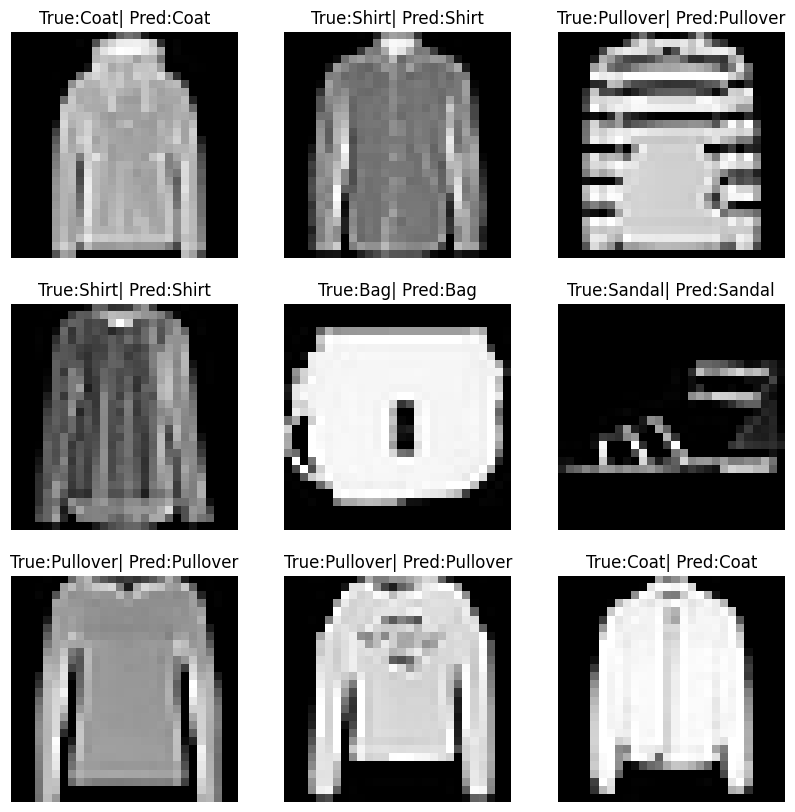

In [56]:
fig=plt.figure(figsize=(10,10))
rows,cols=3,3
for i in range(rows*cols):
  fig.add_subplot(rows,cols,i+1)
  label=class_name[test_labels[i]]
  pred=class_name[pred_classes[i]]
  plt.title(f"True:{label}| Pred:{pred}")
  if(label!=pred):
    plt.imshow(test_sample[i].squeeze(),cmap="Oranges")
  else:
    plt.imshow(test_sample[i].squeeze(),cmap="gray")
  plt.axis(False)


Now lets make a confusion metrix

In [57]:
from tqdm.auto import tqdm

y_preds=[]
model02.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader,desc="making prediction"):
    X,y=X.to(device),y.to(device)
    y_logit=model02(X)
    y_pred=torch.softmax(y_logit,dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor=torch.cat(y_preds)


making prediction:   0%|          | 0/313 [00:00<?, ?it/s]

In [58]:
import mlxtend

In [59]:
mlxtend.__version__

'0.23.4'

In [60]:
!pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.7 MB/s eta 0:00:00


In [61]:
torchmetrics.__version__

'1.9.0'

If we were unable to install torchmetrics and mlxtend then we are going to use this code->

In [62]:
'''
try:
  import torchmetrics ,mlxtend
  print(f"mlxtend version:{mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1] >=19,"mlztend version should be 0.19.0 or higher")
except:
  !pip install torchmetrics -U mlxtend
  import torchmetrics , mlxtendprint(f"mlxtend version: {mlxtend.__version__}")
  '''

'\ntry:\n  import torchmetrics ,mlxtend\n  print(f"mlxtend version:{mlxtend.__version__}")\n  assert int(mlxtend.__version__.split(".")[1] >=19,"mlztend version should be 0.19.0 or higher")\nexcept:\n  !pip install torchmetrics -U mlxtend\n  import torchmetrics , mlxtendprint(f"mlxtend version: {mlxtend.__version__}")\n  '

In [63]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

In [64]:
confmat = ConfusionMatrix(num_classes=len(class_name),task='multiclass')
confmat_tensor=confmat(preds=y_pred_tensor,
                       target=test_data.targets)

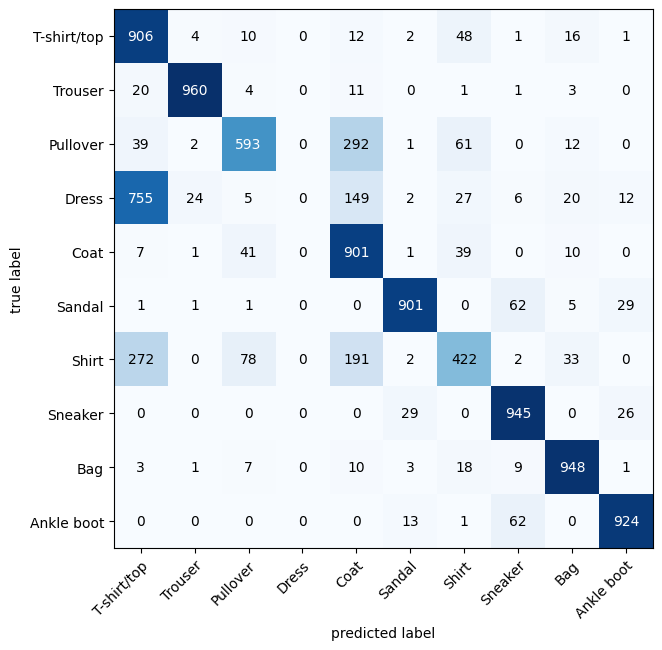

In [65]:
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                class_names=class_name,
                                figsize=(10,7)
                                );

In [66]:
from tqdm.auto import tqdm

y_preds=[]
model03.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader,desc="making prediction"):
    X,y=X.to(device),y.to(device)
    y_logit=model03(X)
    y_pred=torch.softmax(y_logit,dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor01=torch.cat(y_preds)

making prediction:   0%|          | 0/313 [00:00<?, ?it/s]

In [67]:
confmat = ConfusionMatrix(num_classes=len(class_name),task='multiclass')
confmat_tensor01=confmat(preds=y_pred_tensor01,
                       target=test_data.targets)

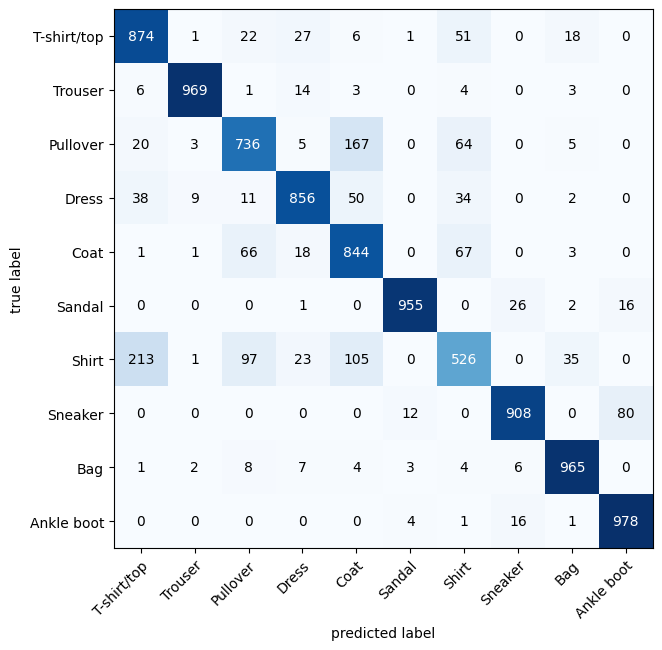

In [68]:
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor01.numpy(),
                                class_names=class_name,
                                figsize=(10,7)
                                );

# Lets Save the model state dict. then load and test it

1-Creating directory

In [69]:
from pathlib import Path

model_path=Path("models")
model_path.mkdir(parents=True,exist_ok=True)


2-Creating file name with path

In [70]:
model_name="model03.pth"
model_save_path=model_path/model_name

3-saving model at right path

In [71]:
torch.save(obj=model03.state_dict(),f=model_save_path)

In [72]:
loaded_model_2=CNNmodel01(input_shape=1,hidden_unit=10,output_shape=10)
loaded_model_2.load_state_dict(torch.load(f=model_save_path))
loaded_model_2=loaded_model_2.to(device)

4-Testing the loaded model

In [73]:
torch.manual_seed(42)
loaded_model_result=model_eval(model=loaded_model_2,
                               data_loader=test_dataloader,
                               loss_fn=loss_fn,
                               accuracy_fn=accuracy_fn)

In [74]:
loaded_model_result

{'model_name': 'CNNmodel01',
 'model_loss': 0.38979023694992065,
 'model_acc': 86.12220447284345}

In [75]:
model03_result

{'model_name': 'CNNmodel01',
 'model_loss': 0.38979023694992065,
 'model_acc': 86.12220447284345}

# Isclose -> This is used to check if the result are same or close , if yes result should be true of isclose function

In [76]:
torch.isclose(torch.tensor(model03_result["model_loss"]),
              torch.tensor(loaded_model_result["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)